# 03. Сравниваем модели

В бейзлайне мы смотрели на пять общих чисел за сутки. Теперь добавим состав действий, темп, разнообразие объявлений и несколько простых признаков из User-Agent. Прогоним четыре подхода по одной схеме: прежнюю логистическую регрессию, расширенную логистическую регрессию, случайный лес и CatBoost.

Главная метрика та же: Precision при Recall не ниже 70%. Все модели обучаются только на датах раньше своего проверочного отрезка. CatBoost и остальные библиотеки работают локально, без внешних API.

Запускай ноутбук из корня проекта. Проверяли на Python 3.12.10, версии библиотек записаны в `requirements.txt`.

In [1]:
# Открой ноутбук из корня проекта или из папки notebooks.
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if not (project_root / "data" / "train.csv").is_file():
    raise FileNotFoundError("Не найдена папка data. Открой ноутбук из проекта.")
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from pathlib import Path
from time import perf_counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from utils.metric import pr_curve, precision_at_recall

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 125, "font.size": 10})
COLORS={"baseline_logreg":"#7f8c8d","rich_logreg":"#3274A1",
        "random_forest":"#57A773","catboost":"#E1812C"}
NAMES={"baseline_logreg":"Логрег, 5 признаков","rich_logreg":"Логрег, больше признаков",
       "random_forest":"Случайный лес","catboost":"CatBoost"}

root=Path("data")
train=pd.read_csv(root/"train.csv",parse_dates=["cookie_created_at","window_start_ts","window_end_ts"])
test=pd.read_csv(root/"test.csv",parse_dates=["cookie_created_at","window_start_ts","window_end_ts"])
events=pd.read_csv(root/"events.csv.gz",parse_dates=["event_ts"])
print(f"Кук в train: {len(train):,}, в test: {len(test):,}; событий: {len(events):,}")

Кук в train: 11,091, в test: 4,909; событий: 328,905


## Не заглядываем за конец окна

Как и в первых ноутбуках, сначала соединяем события с датами кук и отсекаем всё вне `window_start_ts <= event_ts < window_end_ts`. Это важно сделать до любых агрегатов. Например, капча целиком находится после разрешённого окна.

In [2]:
meta=pd.concat([train.assign(split="train"),test.assign(split="test")],ignore_index=True)
original_event_cols=events.columns.tolist()
joined=events.merge(meta[["cookie_id","window_start_ts","window_end_ts"]],
                    on="cookie_id",how="left",validate="many_to_one")
assert joined.window_start_ts.notna().all()
inside=joined.loc[
    joined.event_ts.ge(joined.window_start_ts) & joined.event_ts.lt(joined.window_end_ts)
].copy()
assert not inside.event_name.eq("captcha_shown").any()
print(f"Внутри окна: {len(inside):,} событий, за окном: {len(events)-len(inside):,}")

Внутри окна: 288,126 событий, за окном: 40,779


## Поведение за сутки

Признаки остаются довольно простыми. Считаем действия каждого типа, разные объявления, запросы и локации. Отдельно смотрим на короткие паузы, активность в одну минуту, координаты курсора и повторы. Полный User-Agent не берём: там слишком много версий браузеров, которые могут быстро устареть.

Точные дубли событий пока оставляем в потоке, но добавляем их долю как признак. Если дубли вызваны особенностью логирования, модель хотя бы сможет это заметить. Позже проверим, не зависит ли от них результат слишком сильно.

In [3]:
inside=inside.sort_values(["cookie_id","event_ts"],kind="mergesort")
by_cookie=inside.groupby("cookie_id",sort=False)
inside["gap_sec"]=by_cookie.event_ts.diff().dt.total_seconds()
inside["minute"]=inside.event_ts.dt.floor("min")
inside["hour"]=inside.event_ts.dt.hour
inside["has_pointer"]=inside.pointer_x.notna() & inside.pointer_y.notna()
inside["headless_ua"]=inside.user_agent.str.contains("HeadlessChrome",case=False,na=False)
inside["automation_ua"]=inside.user_agent.str.contains(
    "bot|curl|python|selenium|playwright",case=False,regex=True,na=False
)
inside["platform_group"]=inside.platform.str.lower().replace({"desktop":"web","iphone":"ios"})
inside["same_item_again"]=inside.item_id.notna() & inside.item_id.eq(by_cookie.item_id.shift())
inside["exact_duplicate"]=inside.duplicated(subset=original_event_cols,keep=False)

by_cookie=inside.groupby("cookie_id")
aggregates=by_cookie.agg(
    events=("eid","size"),items=("item_id","nunique"),categories=("item_category","nunique"),
    locations=("item_location","nunique"),queries=("search_query","nunique"),
    ua_count=("user_agent","nunique"),platform_count=("platform_group","nunique"),
    active_hours=("hour","nunique"),first_event=("event_ts","min"),last_event=("event_ts","max"),
    median_gap_sec=("gap_sec","median"),gap_p10_sec=("gap_sec",lambda s:s.quantile(.10)),
    gap_p90_sec=("gap_sec",lambda s:s.quantile(.90)),
    gap_under_5s=("gap_sec",lambda s:s.le(5).mean()),
    gap_under_30s=("gap_sec",lambda s:s.le(30).mean()),
    gap_zero=("gap_sec",lambda s:s.eq(0).mean()),
    pointer_share=("has_pointer","mean"),pointer_x_unique=("pointer_x","nunique"),
    headless_ua=("headless_ua","max"),automation_ua=("automation_ua","max"),
    same_item_share=("same_item_again","mean"),duplicate_share=("exact_duplicate","mean"),
    search_page_max=("search_page","max"),search_page_mean=("search_page","mean"),
)
aggregates["span_minutes"]=(aggregates.last_event-aggregates.first_event).dt.total_seconds()/60
aggregates=aggregates.drop(columns=["first_event","last_event"])
aggregates["max_events_minute"]=inside.groupby(["cookie_id","minute"]).size().groupby(level=0).max()

category_counts=inside.groupby(["cookie_id","item_category"]).size()
category_total=by_cookie.item_category.count()
aggregates["top_category_share"]=category_counts.groupby(level=0).max()/category_total
aggregates["top_category_share"]=aggregates.top_category_share.fillna(0)

Самих типов событий немного, поэтому для каждого добавим число и долю. Доля помогает отличить куку с 30 просмотрами объявлений от куки с 30 разными действиями. Платформы приводим к трём группам: web, android и ios.

In [4]:
event_counts=pd.crosstab(inside.cookie_id,inside.event_name).add_prefix("n_")
aggregates=aggregates.join(event_counts)
for column in event_counts.columns:
    aggregates[column.replace("n_","share_",1)]=aggregates[column]/aggregates.events

platform_counts=pd.crosstab(inside.cookie_id,inside.platform_group)
platform_counts=platform_counts.reindex(columns=["web","android","ios"],fill_value=0)
for platform in platform_counts.columns:
    aggregates[f"share_platform_{platform}"]=platform_counts[platform]/aggregates.events

aggregates["items_per_event"]=aggregates["items"]/aggregates.events
aggregates["queries_per_search"]=(aggregates.queries/(aggregates.n_search_results_view+1))
aggregates["item_views_per_item"]=(aggregates.n_item_view/(aggregates["items"]+1))

features=meta[["cookie_id","split","window_start_ts","cookie_created_at"]].merge(
    aggregates.reset_index(),on="cookie_id",how="left",validate="one_to_one"
)
features["cookie_age_days"]=(features.window_start_ts-features.cookie_created_at).dt.total_seconds()/86400
X_train=features.loc[features.split.eq("train")].reset_index(drop=True)
X_test=features.loc[features.split.eq("test")].reset_index(drop=True)
y=train.target.to_numpy()
assert X_train.cookie_id.equals(train.cookie_id) and X_test.cookie_id.equals(test.cookie_id)
rich_cols=[c for c in aggregates.columns]+["cookie_age_days"]
base_cols=["events","items","queries","median_gap_sec","cookie_age_days"]
assert set(base_cols).issubset(rich_cols) and not set(rich_cols)&{"cookie_id","target","window_start_ts"}
assert features[rich_cols].min().dropna().ge(0).all()
print("Признаков:",len(rich_cols),"| пропуск медианной паузы:",X_train.median_gap_sec.isna().sum())
display(X_train[["cookie_id"]+base_cols].head(3))

Признаков: 50 | пропуск медианной паузы: 247


,cookie_id,events,items,queries,median_gap_sec,cookie_age_days
0,ck_54a059eb7d3ea68b,7,4,3,21.0,135.603692
1,ck_7e4de46eeab82974,41,19,5,57.5,194.576111
2,ck_9320229ef6304522,36,19,10,22.0,32.994421


## Три проверки по времени

Делаем три последовательных отрезка. В каждом модель видит только дни, которые были раньше валидации. Главным для сравнения с бейзлайном остаётся последний отрезок, 17–19 апреля. Два предыдущих покажут, насколько результат устойчив.

In [5]:
folds=[
    ("11–13 апреля","2026-04-11","2026-04-14"),
    ("14–16 апреля","2026-04-14","2026-04-17"),
    ("17–19 апреля","2026-04-17","2026-04-20"),
]
fold_rows=[]
for name,start,end in folds:
    start,end=pd.Timestamp(start),pd.Timestamp(end)
    fit=X_train.window_start_ts.lt(start).to_numpy()
    valid=X_train.window_start_ts.ge(start).to_numpy() & X_train.window_start_ts.lt(end).to_numpy()
    assert X_train.loc[fit,"window_start_ts"].max()<X_train.loc[valid,"window_start_ts"].min()
    fold_rows.append({"отрезок":name,"обучение":fit.sum(),"проверка":valid.sum(),
                      "ботов на проверке":y[valid].sum(),"доля ботов":y[valid].mean()})
display(pd.DataFrame(fold_rows).set_index("отрезок").round(3))

,обучение,проверка,ботов на проверке,доля ботов
отрезок,,,,
11–13 апреля,4217,2556,199,0.078
14–16 апреля,6773,2367,195,0.082
17–19 апреля,9140,1951,160,0.082


## От простой модели к более гибкой

Все подходы получают одинаковые временные отрезки. Расширенная логистическая регрессия, лес и CatBoost видят один и тот же набор из новых признаков. Это позволяет сравнить сами модели, а не только разные наборы колонок.

У логистической регрессии `log1p`, заполнение пропусков и масштабирование учатся внутри пайплайна. Лес получает заполненные пропуски. CatBoost умеет работать с числовыми пропусками сам. Параметры сейчас фиксированные, без подгонки под валидацию.

In [6]:
def make_logreg(regularization=1.0):
    return Pipeline([
        ("log",FunctionTransformer(np.log1p)),
        ("fill",SimpleImputer(strategy="median",add_indicator=True)),
        ("scale",StandardScaler()),
        ("model",LogisticRegression(C=regularization,max_iter=2000,random_state=42)),
    ])

def make_forest():
    return Pipeline([
        ("fill",SimpleImputer(strategy="median",add_indicator=True)),
        ("model",RandomForestClassifier(n_estimators=350,min_samples_leaf=3,
                                        max_features="sqrt",n_jobs=4,random_state=42)),
    ])

def make_catboost():
    return CatBoostClassifier(iterations=600,depth=6,learning_rate=.05,l2_leaf_reg=5,
                              loss_function="Logloss",verbose=False,random_seed=42,
                              thread_count=4,allow_writing_files=False)

models={
    "baseline_logreg":(base_cols,lambda:make_logreg()),
    "rich_logreg":(rich_cols,lambda:make_logreg(.5)),
    "random_forest":(rich_cols,make_forest),
    "catboost":(rich_cols,make_catboost),
}

In [7]:
measurements=[]
validation_scores=[]
for model_key,(columns,build_model) in models.items():
    for fold_name,start,end in folds:
        start,end=pd.Timestamp(start),pd.Timestamp(end)
        fit=X_train.window_start_ts.lt(start).to_numpy()
        valid=X_train.window_start_ts.ge(start).to_numpy() & X_train.window_start_ts.lt(end).to_numpy()
        estimator=build_model()
        clock=perf_counter()
        estimator.fit(X_train.loc[fit,columns],y[fit])
        fit_seconds=perf_counter()-clock
        clock=perf_counter()
        score=estimator.predict_proba(X_train.loc[valid,columns])[:,1]
        predict_seconds=perf_counter()-clock
        measurements.append({
            "model":model_key,"fold":fold_name,
            "p_at_r70":precision_at_recall(y[valid],score),
            "pr_auc":average_precision_score(y[valid],score),
            "fit_seconds":fit_seconds,
            "predict_ms_per_1000":predict_seconds/valid.sum()*1000*1000,
        })
        validation_scores.append(pd.DataFrame({
            "cookie_id":X_train.loc[valid,"cookie_id"].to_numpy(),
            "fold":fold_name,"target":y[valid],"model":model_key,"score":score,
        }))
        print(f"{NAMES[model_key]} | {fold_name}: P@R70 = {measurements[-1]['p_at_r70']:.3f}")

results=pd.DataFrame(measurements)
validation_long=pd.concat(validation_scores,ignore_index=True)
summary=results.pivot(index="model",columns="fold",values="p_at_r70")
summary=summary[[name for name,_,_ in folds]]
summary["среднее"]=summary.mean(axis=1)
summary.index=summary.index.map(NAMES)
display(summary.round(3))

Логрег, 5 признаков | 11–13 апреля: P@R70 = 0.159
Логрег, 5 признаков | 14–16 апреля: P@R70 = 0.149
Логрег, 5 признаков | 17–19 апреля: P@R70 = 0.134
Логрег, больше признаков | 11–13 апреля: P@R70 = 0.323
Логрег, больше признаков | 14–16 апреля: P@R70 = 0.387
Логрег, больше признаков | 17–19 апреля: P@R70 = 0.412


Случайный лес | 11–13 апреля: P@R70 = 0.304


Случайный лес | 14–16 апреля: P@R70 = 0.423


Случайный лес | 17–19 апреля: P@R70 = 0.511


CatBoost | 11–13 апреля: P@R70 = 0.491


CatBoost | 14–16 апреля: P@R70 = 0.529


CatBoost | 17–19 апреля: P@R70 = 0.521


fold,11–13 апреля,14–16 апреля,17–19 апреля,среднее
model,,,,
"Логрег, 5 признаков",0.159,0.149,0.134,0.147
CatBoost,0.491,0.529,0.521,0.514
Случайный лес,0.304,0.423,0.511,0.413
"Логрег, больше признаков",0.323,0.387,0.412,0.374


Время обучения и предсказания тоже запишем, но пока это лишь локальный замер на маленьком файле. По нему нельзя обещать скорость в проде. Для выбора модели важнее, чтобы качество не держалось на одном удачном дне.

,fit_seconds,predict_ms_per_1000
model,,
"Логрег, 5 признаков",0.01,0.44
CatBoost,1.06,1.08
Случайный лес,0.65,12.75
"Логрег, больше признаков",0.03,1.26


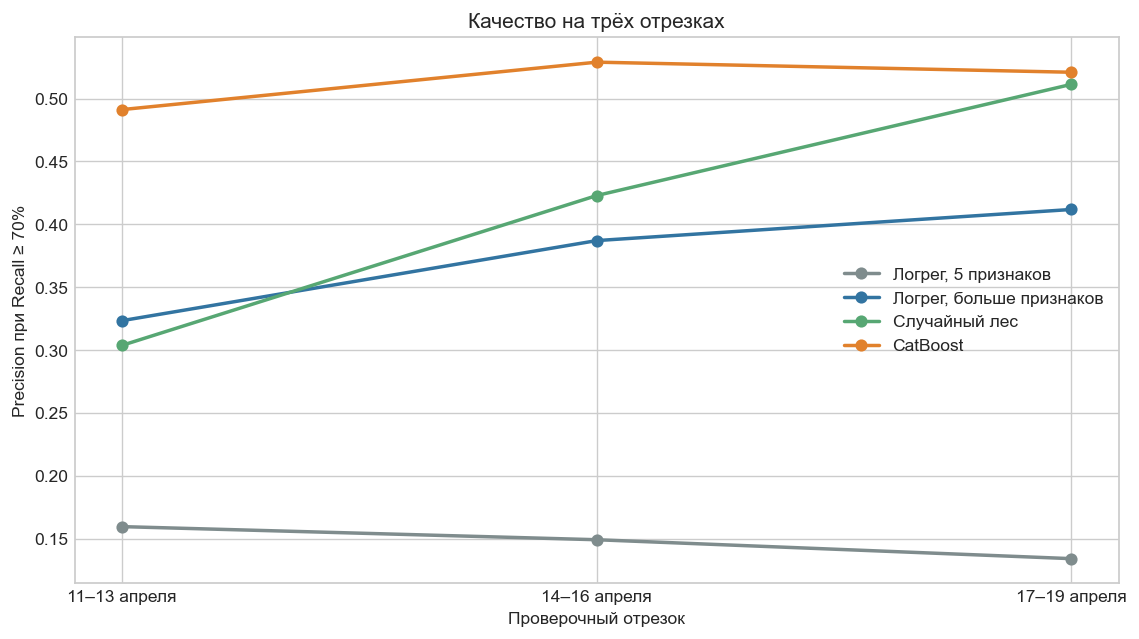

In [8]:
time_table=results.groupby("model")[["fit_seconds","predict_ms_per_1000"]].mean()
time_table.index=time_table.index.map(NAMES)
display(time_table.round(2))

fig,ax=plt.subplots(figsize=(9,5),layout="constrained")
for key,part in results.groupby("model",sort=False):
    part=part.set_index("fold").loc[[name for name,_,_ in folds]]
    ax.plot(part.index,part.p_at_r70,marker="o",linewidth=2,label=NAMES[key],color=COLORS[key])
ax.set(ylabel="Precision при Recall ≥ 70%",xlabel="Проверочный отрезок",
       title="Качество на трёх отрезках")
ax.legend(frameon=False)
plt.show()

Для последнего отрезка посмотрим кривые precision/recall. Высокий PR-AUC сам по себе не гарантирует хорошую точность там, где recall уже достиг 70%. По этой причине итоговые выводы делаем по официальной метрике.

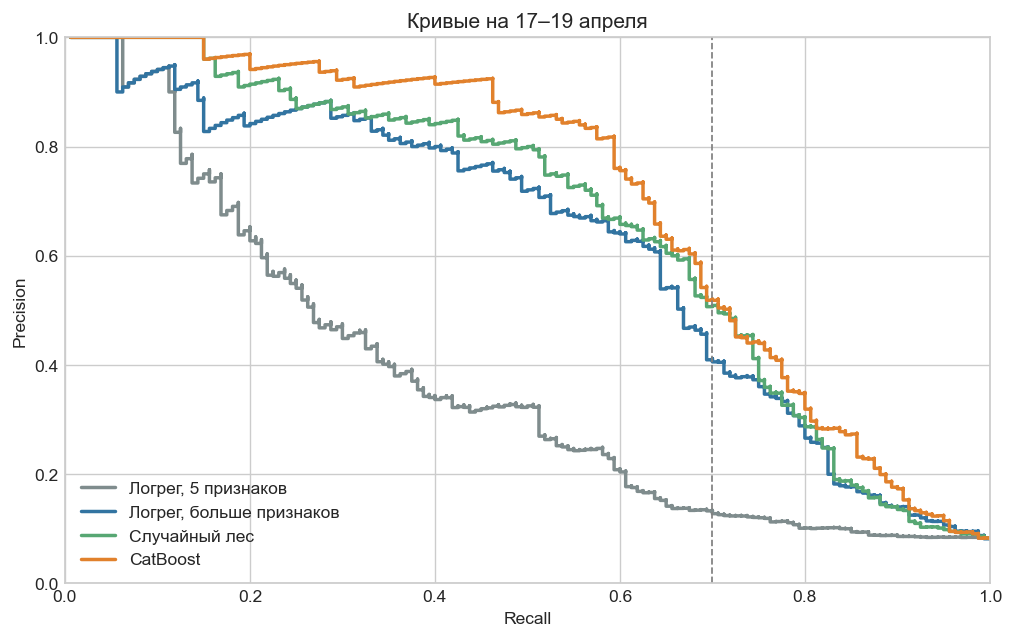

In [9]:
last_fold=folds[-1][0]
last=validation_long.loc[validation_long.fold.eq(last_fold)]
fig,ax=plt.subplots(figsize=(8,5),layout="constrained")
for key in models:
    part=last[last.model.eq(key)]
    precision,recall=pr_curve(part.target,part.score)
    ax.step(recall,precision,where="post",linewidth=2,label=NAMES[key],color=COLORS[key])
ax.axvline(.70,color="gray",linestyle="--",linewidth=1)
ax.set(xlim=(0,1),ylim=(0,1),xlabel="Recall",ylabel="Precision",
       title="Кривые на 17–19 апреля")
ax.legend(frameon=False)
plt.show()

## Проверяем User-Agent

У некоторых известных ботов в строке браузера есть явные подсказки. Это законный признак внутри окна, но на новом сервисе сбора данных он может исчезнуть. Поэтому отдельно обучим CatBoost без трёх признаков User-Agent и посмотрим, сильно ли упадёт качество.

In [10]:
ua_cols=["headless_ua","automation_ua","ua_count"]
no_ua_cols=[column for column in rich_cols if column not in ua_cols]
no_ua_rows=[]
no_ua_predictions=[]
for fold_name,start,end in folds:
    start,end=pd.Timestamp(start),pd.Timestamp(end)
    fit=X_train.window_start_ts.lt(start).to_numpy()
    valid=X_train.window_start_ts.ge(start).to_numpy() & X_train.window_start_ts.lt(end).to_numpy()
    no_ua_model=make_catboost()
    no_ua_model.fit(X_train.loc[fit,no_ua_cols],y[fit])
    score=no_ua_model.predict_proba(X_train.loc[valid,no_ua_cols])[:,1]
    no_ua_rows.append({"отрезок":fold_name,"CatBoost без UA":precision_at_recall(y[valid],score)})
    no_ua_predictions.append(pd.DataFrame({
        "cookie_id":X_train.loc[valid,"cookie_id"].to_numpy(),
        "fold":fold_name,"target":y[valid],"model":"catboost_no_ua","score":score,
    }))
no_ua_table=pd.DataFrame(no_ua_rows).set_index("отрезок")
no_ua_table["CatBoost с UA"]=results.loc[results.model.eq("catboost")].set_index("fold").p_at_r70
no_ua_table["разница"]=no_ua_table["CatBoost с UA"]-no_ua_table["CatBoost без UA"]
display(no_ua_table.round(3))

,CatBoost без UA,CatBoost с UA,разница
отрезок,,,
11–13 апреля,0.461,0.491,0.031
14–16 апреля,0.544,0.529,-0.015
17–19 апреля,0.560,0.521,-0.039


Без User-Agent CatBoost получил 0,461, 0,544 и 0,560 на трёх отрезках. Среднее 0,522, с User-Agent среднее 0,514. Удаление этих признаков почти не вредит, а на двух последних отрезках даже помогает. Значит, улучшение относительно бейзлайна не держится на строке браузера. Три временных отрезка всё ещё не гарантируют тот же результат на совсем новых ботах.

## Сохраняем числа для заключения

Нам ещё предстоит выбрать итоговый подход. Чтобы не пересчитывать все модели в заключительном ноутбуке, сохраним оценки на проверочных отрезках и предсказания для test в `output/`. Это рабочие таблицы, не файл для отправки. Итоговый `submission.csv` позже должен содержать ровно две колонки.

In [11]:
validation_long=pd.concat([validation_long,pd.concat(no_ua_predictions,ignore_index=True)],ignore_index=True)
validation_wide=validation_long.pivot(index=["cookie_id","fold","target"],
                                       columns="model",values="score").reset_index()
validation_wide.columns.name=None
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
validation_path = output_dir / "model_validation_scores.csv"
test_path = output_dir / "model_test_scores.csv"
validation_wide.to_csv(validation_path,index=False,float_format="%.10f")

test_candidates=pd.DataFrame({"cookie_id":test.cookie_id})
for key,(columns,build_model) in models.items():
    estimator=build_model()
    estimator.fit(X_train[columns],y)
    test_candidates[key]=estimator.predict_proba(X_test[columns])[:,1]
    if key=="catboost":
        catboost_full=estimator
no_ua_full=make_catboost()
no_ua_full.fit(X_train[no_ua_cols],y)
test_candidates["catboost_no_ua"]=no_ua_full.predict_proba(X_test[no_ua_cols])[:,1]
test_candidates.to_csv(test_path,index=False,float_format="%.10f")

assert len(validation_wide)==sum(row["проверка"] for row in fold_rows)
assert validation_wide.cookie_id.is_unique
assert validation_wide[[*models,"catboost_no_ua"]].notna().all().all()
assert test_candidates.cookie_id.equals(test.cookie_id)
assert test_candidates.drop(columns="cookie_id").apply(lambda s:s.between(0,1).all()).all()
saved_test=pd.read_csv(test_path)
assert saved_test.cookie_id.equals(test.cookie_id)
print(f"Сохранены {validation_path} и {test_path}")
print("Строк в таблице test:",len(test_candidates))
display(test_candidates.head(3))

Сохранены output/model_validation_scores.csv и output/model_test_scores.csv
Строк в таблице test: 4909


,cookie_id,baseline_logreg,rich_logreg,random_forest,catboost,catboost_no_ua
0,ck_315fb710a0e371e7,0.094759,0.001369,0.015569,0.000673,0.000692
1,ck_a76ee3b3e3e522fd,0.104044,0.095334,0.127464,0.061389,0.043168
2,ck_94c9a4d382689e82,0.080402,0.047142,0.021939,0.042616,0.049059


Какие признаки CatBoost использует сильнее всего? Это не причинное объяснение, но поможет проверить, не вылезла ли наверх случайная техническая деталь.

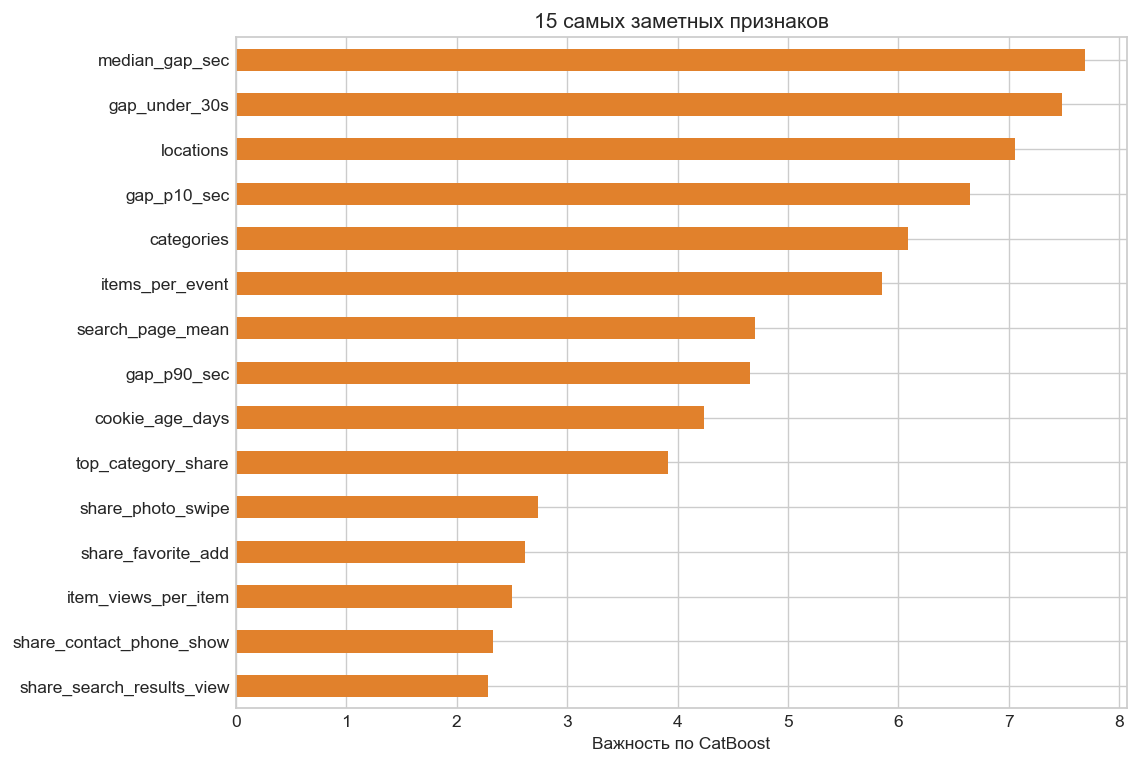

,важность
median_gap_sec,7.69
gap_under_30s,7.48
locations,7.06
gap_p10_sec,6.65
categories,6.09
items_per_event,5.85
search_page_mean,4.70
gap_p90_sec,4.65
cookie_age_days,4.24
top_category_share,3.91


In [12]:
importance=pd.Series(catboost_full.get_feature_importance(),index=rich_cols).sort_values(ascending=False).head(15)
fig,ax=plt.subplots(figsize=(9,6),layout="constrained")
importance.sort_values().plot.barh(ax=ax,color=COLORS["catboost"])
ax.set(xlabel="Важность по CatBoost",title="15 самых заметных признаков")
plt.show()
display(importance.round(2).rename("важность").to_frame())

## Что получилось

Прежний бейзлайн на последнем отрезке снова дал 0,134. Дополнительные признаки подняли логистическую регрессию до 0,412, лес до 0,511, CatBoost до 0,521. CatBoost без User-Agent получил 0,560. На трёх отрезках его среднее тоже чуть выше варианта с User-Agent: 0,522 против 0,514.

У CatBoost наверху признаки темпа действий, разнообразия локаций и категорий. Это похоже на поведение, которое мы хотели уловить. Но важность признака не доказывает причинную связь, а три временных отрезка не заменяют скрытый test. Даже 0,560 precision означает, что при нужном охвате на последней валидации заметная часть отмеченных кук относится к классу 0. Для жёсткой блокировки этого может быть недостаточно.

В заключении сравним устойчивость и стоимость моделей, проверим, даёт ли смешивание оценок пользу, и только потом выберем итоговый файл для отправки.